# Classification of UCI Wine Quality (Red + White) - Evaluation-First Decision Support

Design and Creative Technologies, Torrens University

- **Student:** Luis Guilherme de Barros Andrade Faria - A00187785
- **Subject Name:** Machine Learning
- **Subject Code:** MLN 601
- **Title:** Binary Classification of Wine Quality - Decision Tree, SMOTE and Support Vector Machine
- **Lecturer:** Dr. Kamran Shaukat
- **Assessment No.:** 2
- **Date:** July 2026

| Field | Value |
|---|---|
| Dataset | UCI Wine Quality - red + white combined (Cortez et al., 2009) |
| Task | Binary classification: low (quality < 6) vs high (quality >= 6) |
| Required algorithm | Decision Tree - default, AUC-tuned and recall-focused variants |
| Comparators | Logistic Regression, Gaussian Naive Bayes and kernel SVM |
| Imbalance study | Class weighting and leakage-safe SMOTE sensitivity test |
| Evaluation | ROC-AUC, confusion matrix, sensitivity, specificity, F1, balanced accuracy and G-mean |
| Methodology | CRISP-DM |

This notebook follows the six CRISP-DM stages (Chapman et al., 2000). Assessment 1 predicted
the numerical quality score; Assessment 2 reframes the same measurements as a binary decision:
**should this wine be flagged as likely low quality?** The required Decision Tree remains the
central model. Class weighting, SMOTE and an SVM kernel comparison test whether stronger
low-quality detection or nonlinear separation changes the recommendation.

> Quality is a subjective, ordinal score. The classifier is an interpretable
> **decision-support tool** for human review, not an automated rejection system.

---

## 1. Business Understanding

Wine producers and distributors need a low-cost screen that prioritises batches for expert
tasting. The business question is: *can routine physicochemical measurements identify wines
likely to receive a low quality score?* The UCI data contains 11 laboratory measurements and
an expert score from 0-10 for red and white *vinho verde* wines (Cortez et al., 2009).

Following the brief, **quality < 6 is low (class 1)** and **quality >= 6 is high (class 0)**.
Low quality is deliberately positive because missing a weak batch is the operational risk.
The majority-class baseline provides a minimum floor, while **ROC-AUC** measures ranking
across all thresholds. Week 6 also motivates **sensitivity/recall**: among genuinely low wines,
how many are caught? Because improving sensitivity may create more false alarms, specificity,
precision, F1, balanced accuracy and G-mean are reported alongside it. Success therefore has
two defensible views: strongest overall ranking and strongest low-quality screening without
collapsing performance on high-quality wines.

## 2. Data Understanding

This stage acquires the data, checks its quality, and explores how the physicochemical
features relate to wine quality.

### 2.1 Data acquisition

| Item | Detail |
|---|---|
| Source | UCI Machine Learning Repository - Wine Quality (id 186) |
| Dataset link | https://archive.ics.uci.edu/dataset/186/wine+quality |
| Files | `winequality-red.csv` and `winequality-white.csv` |
| Acquisition | Local CSV copies downloaded from UCI; the loader retains a direct-URL fallback |
| Separator | Semicolon (`;`) |
| Raw rows | 1,599 red + 4,898 white = 6,497 |

The two files describe Portuguese *vinho verde* samples and can support classification or
regression (Cortez et al., 2009; University of California, Irvine, n.d.). They are combined
with a `wine_type` indicator (1 = red, 0 = white).

### 2.2 Variable description

| Variable | Role | Type | Meaning / unit |
|---|---|---|---|
| fixed acidity | Feature | Continuous | Non-volatile acids (g/dm3) |
| volatile acidity | Feature | Continuous | Acetic acid (g/dm3) |
| citric acid | Feature | Continuous | Citric acid (g/dm3) |
| residual sugar | Feature | Continuous | Sugar after fermentation (g/dm3) |
| chlorides | Feature | Continuous | Salt content (g/dm3) |
| free sulfur dioxide | Feature | Continuous | Free SO2 (mg/dm3) |
| total sulfur dioxide | Feature | Continuous | Total SO2 (mg/dm3) |
| density | Feature | Continuous | Density (g/cm3) |
| pH | Feature | Continuous | Acidity/basicity (pH scale) |
| sulphates | Feature | Continuous | Potassium sulphate (g/dm3) |
| alcohol | Feature | Continuous | Alcohol (% by volume) |
| wine_type | Engineered feature | Binary | White = 0, red = 1 |
| quality | Source target | Ordinal integer | Expert sensory score (0-10) |
| quality_label | Model target | Binary | High (>=6) = 0, low (<6) = 1 |

In [1]:
import os
import warnings

os.environ["PYTHONWARNINGS"] = "ignore"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, balanced_accuracy_score)

try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
except ImportError as exc:
    raise ImportError(
        "Install the Assessment2 requirements first: "
        "python -m pip install -r requirements.txt"
    ) from exc

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [2]:
from pathlib import Path

# Resolve project folders relative to the notebook location so the same notebook
# runs locally and on Colab/Azure without editing paths.
NB_DIR = Path.cwd()
BASE_DIR = NB_DIR.parent if NB_DIR.name == "notebook" else NB_DIR
OUTPUT_DIR = BASE_DIR / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

UCI_BASE = ("https://archive.ics.uci.edu/ml/machine-learning-databases/"
            "wine-quality/")


def load_wine(colour):
    fname = f"winequality-{colour}.csv"
    candidates = [BASE_DIR / "dataset" / fname,
                  NB_DIR / "dataset" / fname,
                  NB_DIR / fname]
    local = next((p for p in candidates if p.exists()), None)
    if local is not None:
        print("Loading local:", local)
        return pd.read_csv(local, sep=";")
    print("Loading from UCI URL:", UCI_BASE + fname)
    return pd.read_csv(UCI_BASE + fname, sep=";")


red = load_wine("red")
white = load_wine("white")
red["wine_type"] = 1    # 1 = red
white["wine_type"] = 0  # 0 = white
df = pd.concat([red, white], ignore_index=True)

print("Red:", red.shape, "| White:", white.shape, "| Combined:", df.shape)
df.head()

Loading local: /Users/luisfaria/Desktop/sEngineer/masters_SWEAI/2026-T2/MLN/assignments/Assessment2/dataset/winequality-red.csv
Loading local: /Users/luisfaria/Desktop/sEngineer/masters_SWEAI/2026-T2/MLN/assignments/Assessment2/dataset/winequality-white.csv
Red: (1599, 13) | White: (4898, 13) | Combined: (6497, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine_type             6497 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 660.0 KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,6497.0,7.215307,1.296434,3.80000,6.40000,7.00000,7.70000,15.90000
volatile acidity,6497.0,0.339666,0.164636,0.08000,0.23000,0.29000,0.40000,1.58000
citric acid,6497.0,0.318633,0.145318,0.00000,0.25000,0.31000,0.39000,1.66000
residual sugar,6497.0,5.443235,4.757804,0.60000,1.80000,3.00000,8.10000,65.80000
chlorides,6497.0,0.056034,0.035034,0.00900,0.03800,0.04700,0.06500,0.61100
free sulfur dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000
total sulfur dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6497.0,3.218501,0.160787,2.72000,3.11000,3.21000,3.32000,4.01000
sulphates,6497.0,0.531268,0.148806,0.22000,0.43000,0.51000,0.60000,2.00000


In [5]:
print("Missing values per column:")
print(df.isna().sum().to_string())
print("\nRaw rows:", len(df))
print("Exact duplicate rows:", int(df.duplicated().sum()))

Missing values per column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
wine_type               0

Raw rows: 6497
Exact duplicate rows: 1177


### 2.3 The classification target

The brief defines **quality < 6 -> low (1)** and **quality >= 6 -> high (0)**. Low quality
is positive because it triggers review. Exact duplicates are removed before target creation and
splitting so identical observations cannot cross validation boundaries. Moderate class imbalance
makes accuracy alone an unsafe summary.

Raw rows: 6497 | duplicates removed: 1177 | unique rows: 5320

Class counts:
quality_label
high (>=6)    3332
low (<6)      1988

Class proportions:
quality_label
high (>=6)    0.626
low (<6)      0.374


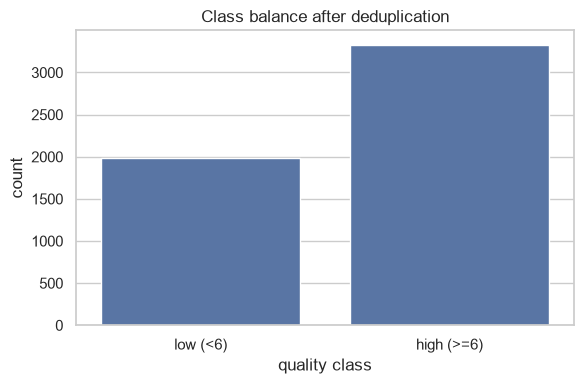

In [6]:
# Remove exact source-record duplicates before target engineering or splitting.
raw_rows = len(df)
duplicate_rows = int(df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Raw rows:", raw_rows,
      "| duplicates removed:", duplicate_rows,
      "| unique rows:", len(df))

# Brief's encoding: quality < 6 -> low (1, positive class); quality >= 6 -> high (0)
df["quality_label"] = (df["quality"] < 6).astype(int)
label_names = {0: "high (>=6)", 1: "low (<6)"}
df["quality_name"] = df["quality_label"].map(label_names)

counts = df["quality_label"].value_counts().sort_index()
print("\nClass counts:")
print(counts.rename(index=label_names).to_string())
print("\nClass proportions:")
print((counts / len(df)).round(3).rename(index=label_names).to_string())

plt.figure(figsize=(6, 4))
sns.countplot(x="quality_name", data=df, order=["low (<6)", "high (>=6)"])
plt.title("Class balance after deduplication")
plt.xlabel("quality class")
plt.ylabel("count")
plt.tight_layout()
plt.savefig(FIG_DIR / "v4_class_balance.png", dpi=120)
plt.show()

### 2.4 Feature relationships

The correlation heatmap and the seaborn **pairplot** (required by the brief) show how the
features move with each other and with quality. `alcohol` shows the clearest separation
between high and low wines, while several acidity and sulfur-dioxide measures are
correlated with each other - a hint that a non-linear model able to capture interactions
may do well.

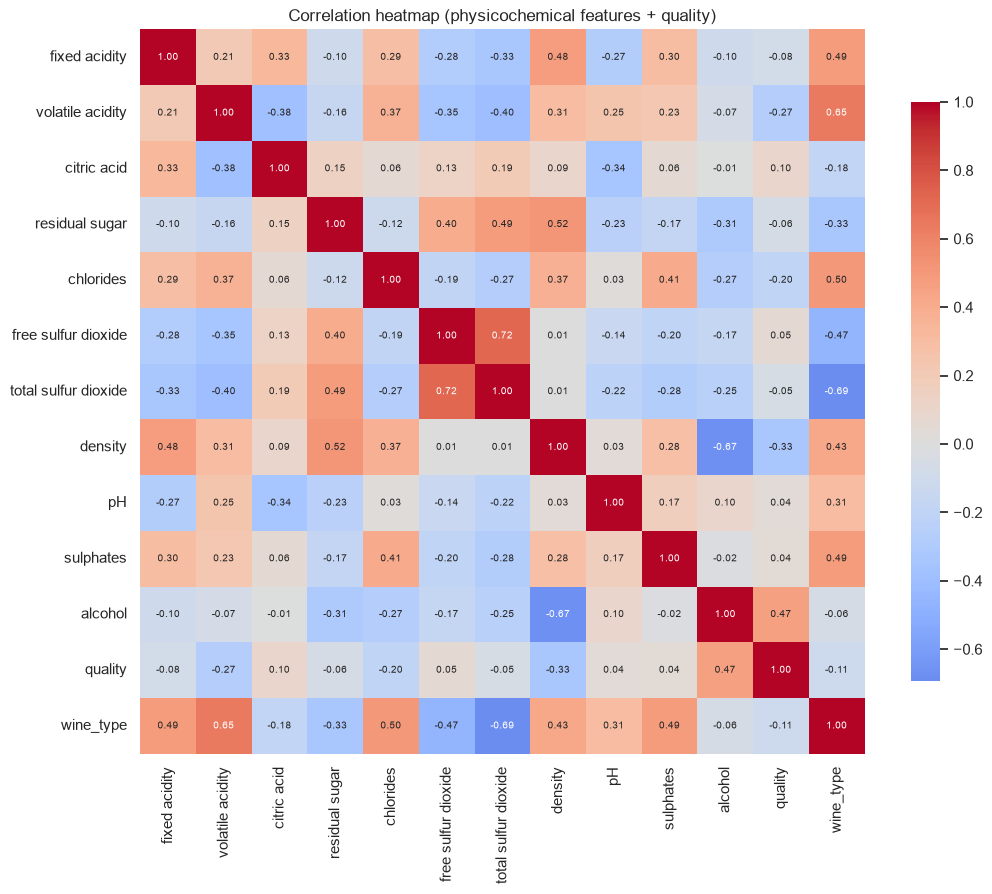

In [7]:
plt.figure(figsize=(11, 9))
corr = df.drop(columns=["quality_label"]).corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": 0.8}, annot_kws={"size": 7})
plt.title("Correlation heatmap (physicochemical features + quality)")
plt.tight_layout()
plt.savefig(FIG_DIR / "v4_corr_heatmap.png", dpi=120)
plt.show()

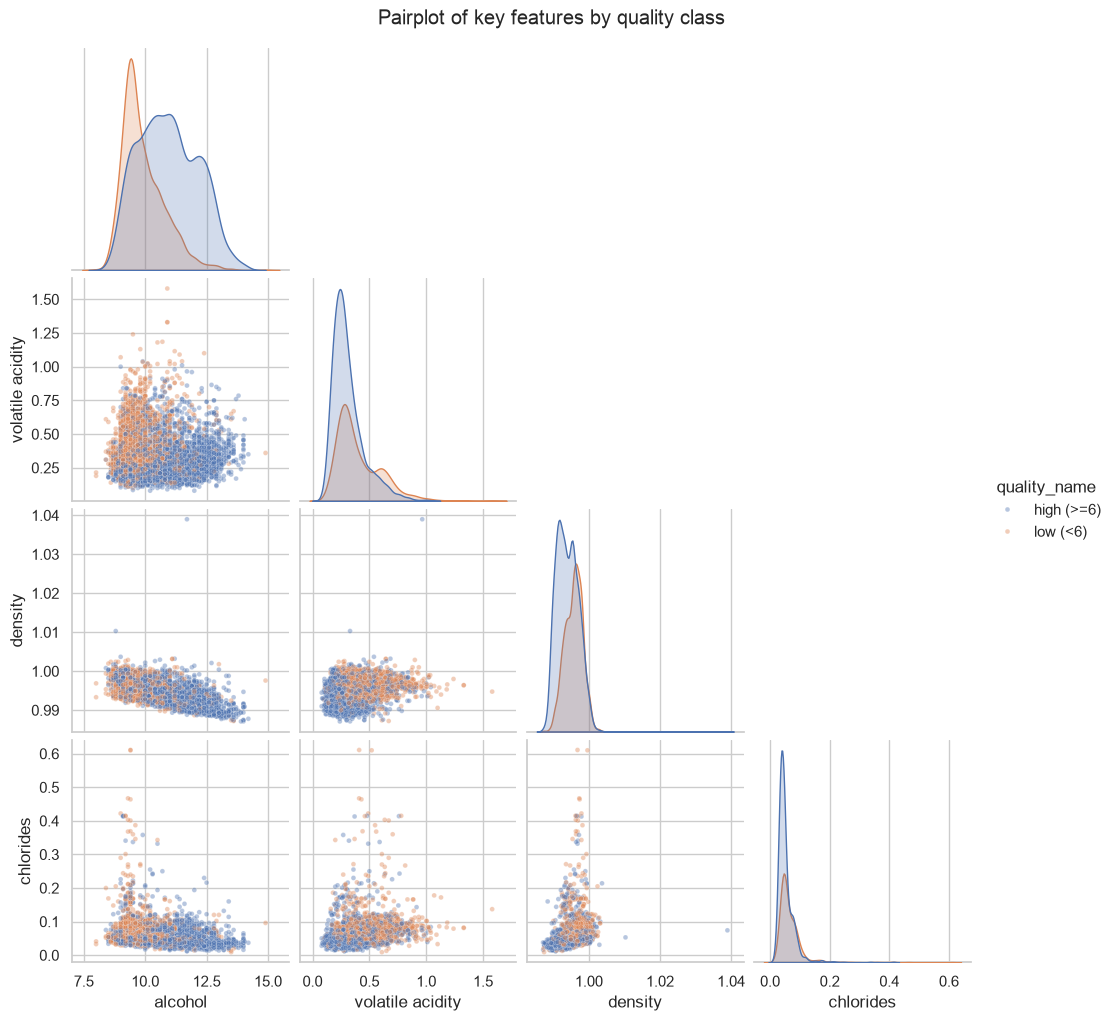

In [8]:
pair_cols = ["alcohol", "volatile acidity", "density", "chlorides"]
g = sns.pairplot(df, vars=pair_cols, hue="quality_name",
                 hue_order=["high (>=6)", "low (<6)"], corner=True,
                 plot_kws={"alpha": 0.4, "s": 12}, diag_kind="kde")
g.fig.suptitle("Pairplot of key features by quality class", y=1.02)
g.savefig(FIG_DIR / "v4_pairplot.png", dpi=110)
plt.show()

**Interpretation:** Three things stand out:

- There are **no missing values**, so no imputation is needed; 1,177 exact duplicates are
  removed before modelling to protect the held-out test set.
- `alcohol` has the strongest positive association with high quality, while `volatile
  acidity` has the clearest negative one.
- Several features are mutually correlated, including the two sulfur-dioxide measures and
  `density` with `alcohol` and `residual sugar`.

Collinearity can destabilise a linear model's coefficients but affects a Decision Tree less
because it splits one feature at a time. The pairplot also shows substantial class overlap,
so a useful but imperfect classifier is more realistic than near-perfect separation.

## 3. Data Preparation

Preparation follows four safeguards. **First**, 1,177 exact records are removed before the
split; otherwise repeated rows can leak into the test set. **Second**, the original `quality`
score and derived labels are excluded from predictors, while `wine_type` remains available.
**Third**, an 80/20 stratified split with `random_state=42` preserves class proportions and is
checked for zero exact overlap. **Fourth**, scale-sensitive models place `StandardScaler`
inside a Pipeline so it is fitted separately within each training fold (Pedregosa et al., 2011).

Decision Trees need no scaling because threshold splits preserve feature ordering. SMOTE is
also placed inside an `imblearn` Pipeline and runs only within training folds. The held-out test
set retains its natural distribution, preventing synthetic observations from contaminating the
final evaluation (Chawla et al., 2002).

In [9]:
LEAK_COLS = ["quality", "quality_label", "quality_name"]
feature_cols = [c for c in df.columns if c not in LEAK_COLS]
X = df[feature_cols]
y = df["quality_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

# Exact feature rows must not cross the train/test boundary after deduplication.
train_keys = pd.MultiIndex.from_frame(X_train)
test_keys = pd.MultiIndex.from_frame(X_test)
overlap_count = int(test_keys.isin(train_keys).sum())
assert overlap_count == 0, "Exact feature rows leaked across train/test split"

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Exact train/test feature overlap:", overlap_count)
print("\nTrain class balance:")
print(y_train.value_counts(normalize=True).round(3).rename(index=label_names).to_string())
print("Test class balance:")
print(y_test.value_counts(normalize=True).round(3).rename(index=label_names).to_string())
print("\nFeatures used (%d):" % len(feature_cols), feature_cols)

Train: (4256, 12) | Test: (1064, 12)
Exact train/test feature overlap: 0

Train class balance:
quality_label
high (>=6)    0.626
low (<6)      0.374
Test class balance:
quality_label
high (>=6)    0.626
low (<6)      0.374

Features used (12): ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'wine_type']


## 4. Modelling

The experiment is evaluation-first rather than a model-count exercise:

1. **Majority baseline** establishes the no-skill floor.
2. **Default Decision Tree** shows the overfitting cost before pruning.
3. **AUC-tuned Decision Tree** is the required model. Five-fold `GridSearchCV` searches
   depth, minimum leaf size and split criterion on training data only.
4. **Balanced Decision Tree** freezes the tuned structure and changes only
   `class_weight="balanced"`. This controlled intervention increases the penalty for missing
   minority low-quality wines.
5. **SMOTE Decision Tree** freezes the same tree structure and tunes only the number of
   neighbours used to synthesise minority training examples. SMOTE remains inside each fold.
6. **RBF/linear/polynomial/sigmoid SVM** tests nonlinear separation. A Support Vector Machine
   seeks a large-margin boundary defined by the closest observations, the support vectors
   (Cortes & Vapnik, 1995). `C` trades a wider margin against training violations; kernels
   provide nonlinear boundaries, while `gamma` controls the locality of RBF influence.

Logistic Regression and Gaussian Naive Bayes remain compact context from earlier modules.
Every search uses five folds and `n_jobs=1`; the test set is touched only in Evaluation.

In [10]:
# 1) Majority-class baseline
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

# 2) Default (untuned) Decision Tree
dt_default = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_default.fit(X_train, y_train)

# 3) Required Decision Tree tuned for the brief's headline ROC-AUC metric.
# Class weighting is excluded here so its effect can be tested separately.
tree_grid = {
    "max_depth": [3, 4, 5, 6, 8, None],
    "min_samples_leaf": [1, 5, 10, 20],
    "criterion": ["gini", "entropy"],
}
grid = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    tree_grid, scoring="roc_auc", cv=5, n_jobs=1)
grid.fit(X_train, y_train)
dt_auc = grid.best_estimator_

# 4) Controlled recall intervention: same learned structure, balanced class costs.
tree_structure = {
    "criterion": grid.best_params_["criterion"],
    "max_depth": grid.best_params_["max_depth"],
    "min_samples_leaf": grid.best_params_["min_samples_leaf"],
}
dt_balanced = DecisionTreeClassifier(
    **tree_structure, class_weight="balanced", random_state=RANDOM_STATE)
dt_balanced.fit(X_train, y_train)

# 5) Leakage-safe SMOTE sensitivity study. Only k-neighbours is tuned; tree
# structure stays fixed for a fair class-weight versus synthetic-data comparison.
smote_pipe = ImbPipeline([
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("tree", DecisionTreeClassifier(**tree_structure, random_state=RANDOM_STATE)),
])
smote_grid = GridSearchCV(
    smote_pipe,
    {"smote__k_neighbors": [3, 5, 7]},
    scoring="balanced_accuracy", cv=5, n_jobs=1)
smote_grid.fit(X_train, y_train)
dt_smote = smote_grid.best_estimator_

# 6) SVM kernel comparison. Scaling is fitted inside every cross-validation fold.
svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC()),
])
svm_grid = [
    {"svc__kernel": ["linear"], "svc__C": [0.1, 1, 10]},
    {"svc__kernel": ["rbf"], "svc__C": [0.1, 1, 10],
     "svc__gamma": ["scale", "auto"]},
    {"svc__kernel": ["poly"], "svc__C": [0.1, 1, 10],
     "svc__gamma": ["scale", "auto"], "svc__degree": [2, 3]},
    {"svc__kernel": ["sigmoid"], "svc__C": [0.1, 1, 10],
     "svc__gamma": ["scale", "auto"]},
]
svm_search = GridSearchCV(
    svm_pipe, svm_grid, scoring="roc_auc", cv=5, n_jobs=1,
    return_train_score=False)
svm_search.fit(X_train, y_train)
svm_best = svm_search.best_estimator_

# Context models from earlier modules.
logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])
logreg.fit(X_train, y_train)
nb = GaussianNB().fit(X_train, y_train)

models = {
    "Majority baseline": dummy,
    "Decision Tree (default)": dt_default,
    "Decision Tree (AUC-tuned)": dt_auc,
    "Decision Tree (balanced)": dt_balanced,
    "Decision Tree (SMOTE)": dt_smote,
    "Logistic Regression": logreg,
    "Naive Bayes (Gaussian)": nb,
    "SVM (best kernel)": svm_best,
}

print("Tree best params:", grid.best_params_)
print("Tree best CV ROC-AUC: %.3f" % grid.best_score_)
print("SMOTE best params:", smote_grid.best_params_)
print("SMOTE best CV balanced accuracy: %.3f" % smote_grid.best_score_)
print("SVM best params:", svm_search.best_params_)
print("SVM best CV ROC-AUC: %.3f" % svm_search.best_score_)

Tree best params: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 20}
Tree best CV ROC-AUC: 0.791
SMOTE best params: {'smote__k_neighbors': 5}
SMOTE best CV balanced accuracy: 0.717
SVM best params: {'svc__C': 1, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
SVM best CV ROC-AUC: 0.826


### 4.2 Selected hyperparameters

The AUC search selects tree structure without the test set. Class weighting then changes only
error cost; SMOTE tunes only neighbour count inside training folds. The SVM search tests whether
linear or nonlinear geometry best handles the overlapping classes. Results are saved for traceability.

In [11]:
best_params = pd.Series(grid.best_params_, dtype="object").astype(str)
best_params.loc["cv_roc_auc"] = round(grid.best_score_, 4)
best_params.to_csv(OUTPUT_DIR / "tree_best_params_v4.csv", header=["value"])

smote_results = (pd.DataFrame(smote_grid.cv_results_)
                 [["param_smote__k_neighbors", "mean_test_score", "std_test_score", "rank_test_score"]]
                 .sort_values("rank_test_score"))
smote_results.to_csv(OUTPUT_DIR / "smote_results_v4.csv", index=False)

svm_cv = pd.DataFrame(svm_search.cv_results_)
svm_kernel_results = (svm_cv.assign(kernel=svm_cv["param_svc__kernel"].astype(str))
                      .groupby("kernel", as_index=False)["mean_test_score"].max()
                      .rename(columns={"mean_test_score": "best_cv_roc_auc"})
                      .sort_values("best_cv_roc_auc", ascending=False))
svm_kernel_results.to_csv(OUTPUT_DIR / "svm_kernel_results_v4.csv", index=False)

display(best_params.to_frame("value"))
display(smote_results.round(4))
display(svm_kernel_results.round(4))

,value
criterion,gini
max_depth,5
min_samples_leaf,20
cv_roc_auc,0.791


,param_smote__k_neighbors,mean_test_score,std_test_score,rank_test_score
1,5,0.7173,0.0116,1
0,3,0.7144,0.0122,2
2,7,0.7131,0.0181,3


,kernel,best_cv_roc_auc
2,rbf,0.8265
0,linear,0.8043
1,poly,0.7950
3,sigmoid,0.7027


## 5. Evaluation

All models are now judged on the untouched test set. The confusion matrix uses **low quality as
positive**: TP is a weak wine correctly flagged; FN is a weak wine missed; FP is a high wine
unnecessarily sent for review; TN is a high wine correctly cleared.

- **Sensitivity/recall = TP / (TP + FN):** proportion of genuinely low wines caught.
- **Specificity = TN / (TN + FP):** proportion of genuinely high wines cleared.
- **Precision:** proportion of low-quality flags that are correct.
- **F1:** harmonic balance of precision and recall.
- **Balanced accuracy:** mean of sensitivity and specificity.
- **G-mean:** geometric mean of sensitivity and specificity; either weak side lowers it.
- **ROC-AUC:** ranking quality across every threshold. The ROC plots sensitivity against the
  false-positive rate; 0.5 is random and 1.0 is perfect.

This distinction matters: AUC asks whether risk scores are ordered well, whereas the confusion
matrix evaluates one operating threshold. Therefore the strongest ranker need not be the model
that catches the most low-quality wines.

In [12]:
def model_scores(model, X_te):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_te)[:, 1]
    return model.decision_function(X_te)


def class_metrics(model, X_te, y_te):
    pred = model.predict(X_te)
    score = model_scores(model, X_te)
    tn, fp, fn, tp = confusion_matrix(y_te, pred, labels=[0, 1]).ravel()
    sensitivity = recall_score(y_te, pred, pos_label=1, zero_division=0)
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    return {
        "accuracy": accuracy_score(y_te, pred),
        "precision_low": precision_score(y_te, pred, pos_label=1, zero_division=0),
        "sensitivity_low": sensitivity,
        "specificity_high": specificity,
        "f1_low": f1_score(y_te, pred, pos_label=1, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_te, pred),
        "g_mean": np.sqrt(sensitivity * specificity),
        "roc_auc": roc_auc_score(y_te, score),
        "tn": tn, "fp": fp, "fn": fn, "tp": tp,
    }


results_full = pd.DataFrame(
    {name: class_metrics(model, X_test, y_test) for name, model in models.items()}
).T
results_full.index.name = "model"
results_full.to_csv(OUTPUT_DIR / "model_metrics_v4.csv")

metric_cols = ["accuracy", "precision_low", "sensitivity_low", "specificity_high",
               "f1_low", "balanced_accuracy", "g_mean", "roc_auc"]
results_full[metric_cols].round(3)

,accuracy,precision_low,sensitivity_low,specificity_high,f1_low,balanced_accuracy,g_mean,roc_auc
model,,,,,,,,
Majority baseline,0.626,0.000,0.000,1.000,0.000,0.500,0.000,0.500
Decision Tree (default),0.682,0.579,0.555,0.758,0.567,0.657,0.649,0.657
Decision Tree (AUC-tuned),0.739,0.672,0.588,0.829,0.627,0.708,0.698,0.793
Decision Tree (balanced),0.728,0.615,0.734,0.725,0.669,0.729,0.729,0.792
Decision Tree (SMOTE),0.733,0.627,0.709,0.748,0.665,0.728,0.728,0.787
Logistic Regression,0.744,0.706,0.543,0.865,0.614,0.704,0.685,0.813
Naive Bayes (Gaussian),0.671,0.579,0.442,0.808,0.501,0.625,0.598,0.736
SVM (best kernel),0.762,0.723,0.590,0.865,0.650,0.728,0.715,0.824


In [13]:
report = classification_report(
    y_test, dt_balanced.predict(X_test),
    target_names=["high (>=6)", "low (<6)"],
    output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T.round(3)
report_df.to_csv(OUTPUT_DIR / "classification_report_v4.csv")
report_df

,precision,recall,f1-score,support
high (>=6),0.820,0.725,0.770,666.000
low (<6),0.615,0.734,0.669,398.000
accuracy,0.728,0.728,0.728,0.728
macro avg,0.717,0.729,0.719,1064.000
weighted avg,0.743,0.728,0.732,1064.000


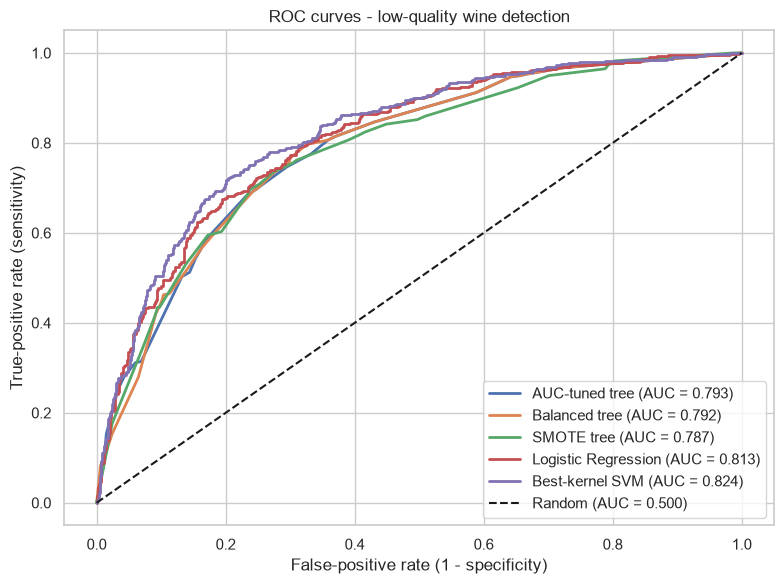

In [14]:
roc_models = {
    "AUC-tuned tree": dt_auc,
    "Balanced tree": dt_balanced,
    "SMOTE tree": dt_smote,
    "Logistic Regression": logreg,
    "Best-kernel SVM": svm_best,
}

plt.figure(figsize=(8, 6))
for name, model in roc_models.items():
    score = model_scores(model, X_test)
    fpr, tpr, _ = roc_curve(y_test, score, pos_label=1)
    auc = roc_auc_score(y_test, score)
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.500)")
plt.xlabel("False-positive rate (1 - specificity)")
plt.ylabel("True-positive rate (sensitivity)")
plt.title("ROC curves - low-quality wine detection")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIG_DIR / "v4_roc_curves.png", dpi=120)
plt.show()

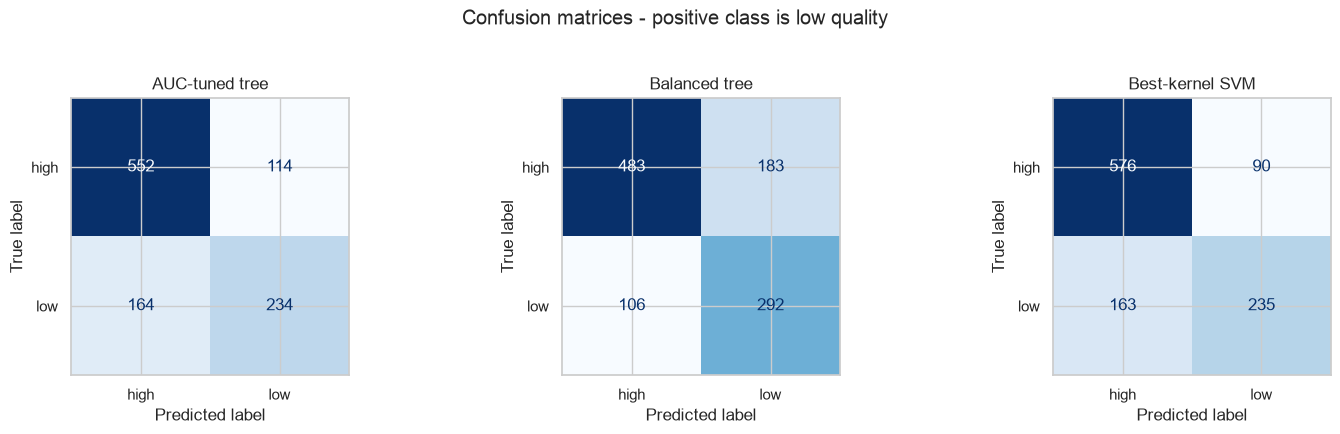

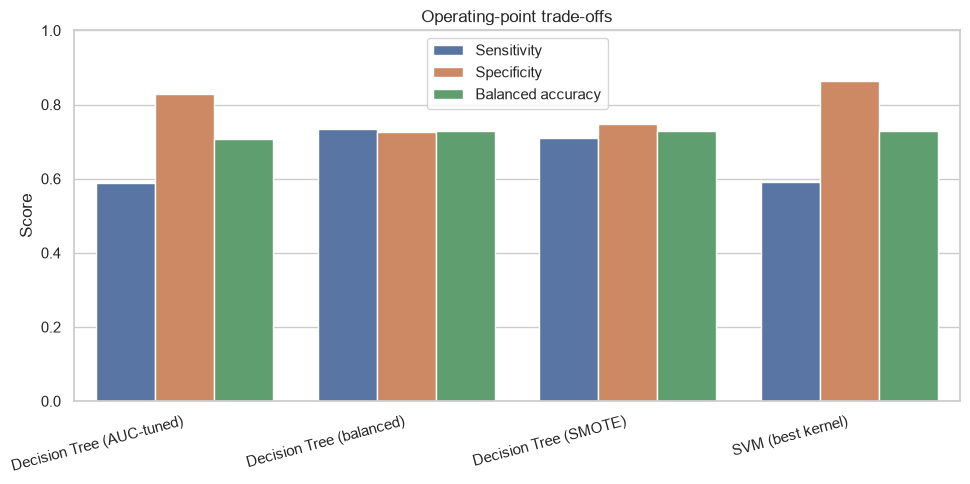

In [15]:
comparison_models = {
    "AUC-tuned tree": dt_auc,
    "Balanced tree": dt_balanced,
    "Best-kernel SVM": svm_best,
}
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, (name, model) in zip(axes, comparison_models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test), labels=[0, 1])
    ConfusionMatrixDisplay(cm, display_labels=["high", "low"]).plot(
        ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)
fig.suptitle("Confusion matrices - positive class is low quality", y=1.03)
plt.tight_layout()
plt.savefig(FIG_DIR / "v4_confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()

balance_plot = (results_full.loc[["Decision Tree (AUC-tuned)",
                                  "Decision Tree (balanced)",
                                  "Decision Tree (SMOTE)",
                                  "SVM (best kernel)"],
                                 ["sensitivity_low", "specificity_high", "balanced_accuracy"]]
                .rename(columns={"sensitivity_low": "Sensitivity",
                                 "specificity_high": "Specificity",
                                 "balanced_accuracy": "Balanced accuracy"})
                .reset_index().melt(id_vars="model", var_name="metric", value_name="score"))
plt.figure(figsize=(10, 5))
sns.barplot(data=balance_plot, x="model", y="score", hue="metric")
plt.ylim(0, 1)
plt.xlabel("")
plt.ylabel("Score")
plt.title("Operating-point trade-offs")
plt.xticks(rotation=15, ha="right")
plt.legend(title="")
plt.tight_layout()
plt.savefig(FIG_DIR / "v4_operating_tradeoffs.png", dpi=120)
plt.show()

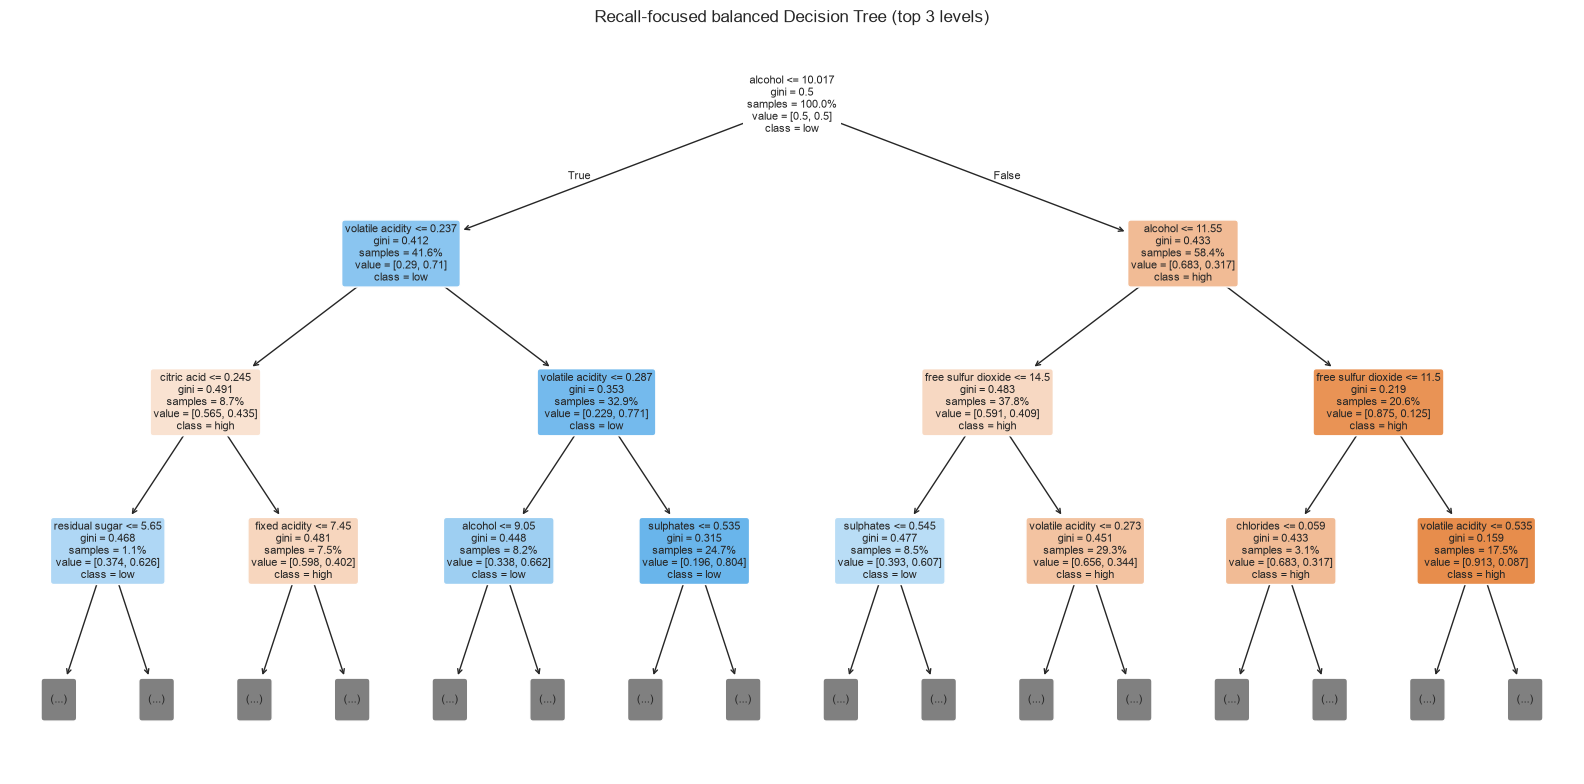

In [16]:
plt.figure(figsize=(16, 8))
plot_tree(dt_balanced, feature_names=feature_cols, class_names=["high", "low"],
          filled=True, rounded=True, max_depth=3, fontsize=8,
          impurity=True, proportion=True)
plt.title("Recall-focused balanced Decision Tree (top 3 levels)")
plt.tight_layout()
plt.savefig(FIG_DIR / "v4_decision_tree.png", dpi=110)
plt.show()

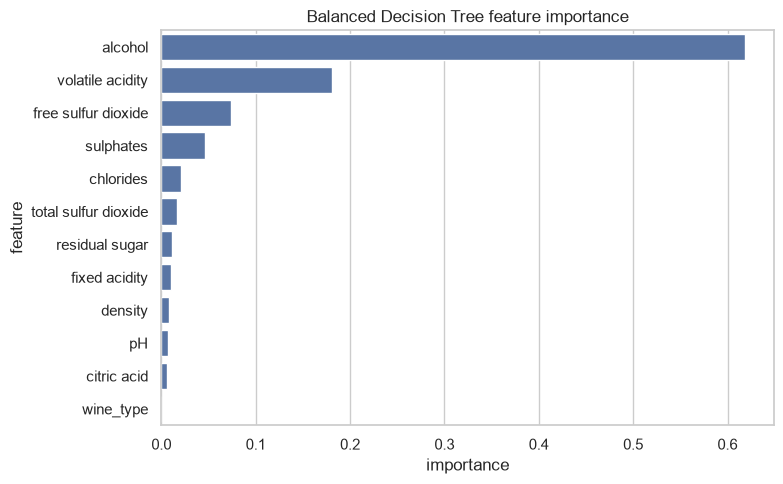

,feature,importance
0,alcohol,0.618359
1,volatile acidity,0.180513
2,free sulfur dioxide,0.073486
3,sulphates,0.046002
4,chlorides,0.020544
5,total sulfur dioxide,0.016899
6,residual sugar,0.011502
7,fixed acidity,0.010528
8,density,0.008234
9,pH,0.007513


In [17]:
importance = (pd.DataFrame({"feature": feature_cols,
                            "importance": dt_balanced.feature_importances_})
              .sort_values("importance", ascending=False)
              .reset_index(drop=True))
importance.to_csv(OUTPUT_DIR / "feature_importance_v4.csv", index=False)

plt.figure(figsize=(8, 5))
sns.barplot(x="importance", y="feature", data=importance)
plt.title("Balanced Decision Tree feature importance")
plt.tight_layout()
plt.savefig(FIG_DIR / "v4_feature_importance.png", dpi=120)
plt.show()
importance

### 5.1 Results and model choice

The AUC-tuned tree reaches **AUC 0.793**, sensitivity **0.588** and specificity **0.829**.
It ranks wines well and clears high-quality wines reliably, but misses 164 of 398 genuinely low
wines. The balanced tree changes only class cost. It catches 292 low wines, lifting sensitivity
to **0.734**, F1 to **0.669**, balanced accuracy to **0.729** and G-mean to **0.729**, while AUC
remains **0.792**. The cost is 69 additional false alarms: specificity falls to **0.725**. This
is an operational trade-off, not a free improvement.

SMOTE also increases sensitivity, reaching **0.709**, but does not beat class weighting on recall,
F1 or balanced accuracy. Its AUC of **0.787** is slightly lower. For this dataset, changing error
costs is therefore simpler and marginally stronger than synthesising minority observations.

The kernel search selects **RBF with C=1 and gamma=`scale`**. It achieves the highest test
**AUC of 0.824** and accuracy of **0.762**, showing that nonlinear geometry captures useful signal
beyond the tree and linear boundary. However, at its default threshold its sensitivity is only
**0.590**, while specificity is **0.865**. There are consequently two winners: the **RBF SVM is
the technical ranking winner**, while the **balanced Decision Tree is the operational screening
winner** when missing a low-quality wine is more costly. The tree also retains visible rules and
feature importance, making its recommendation easier for quality-control staff to challenge.

### 5.2 Why the trade-off is expected

The AUC tree optimises ordering across thresholds, not recall at one threshold. Equal class weight
makes a missed low wine more expensive, shifting performance toward sensitivity and away from
specificity. SMOTE addresses the same imbalance with synthetic minority training examples.

SVM supplies different geometry: linear tests one straight boundary, while other kernels permit
nonlinear separation. This is justified by pairplot overlap, not model accumulation. Gaussian
Naive Bayes remains useful context, although correlated features violate its conditional-
independence assumption (Domingos & Pazzani, 1997).

## 6. Deployment / Lessons Learned

For this assessment, deployment means selecting a defensible decision-support policy rather than
publishing an automated service.

**What worked:** deduplication produced a genuinely unseen test set; AUC tuning raised the required
tree well above random ranking; class weighting then improved low-quality sensitivity from 0.588
to 0.734 without materially changing AUC. The kernel study supplied evidence that an RBF boundary
ranks this overlapping dataset best. **What did not win:** SMOTE improved sensitivity relative to
the AUC tree but remained slightly behind class weighting, so extra synthetic data is not justified
as the preferred intervention. **What changed conceptually:** no single score defines the best
model. SVM wins ranking, while the balanced tree wins the operational objective and interpretability.

Before real use, the threshold should be chosen from the actual cost of a missed weak batch versus
an unnecessary tasting. External validation should use wines from another producer or collection
period. Probability calibration and subgroup monitoring by wine type would also be required. The
main lesson is that model choice and operating threshold answer different questions: the strongest
ranker is not automatically the safest screening policy.

---

## Academic Integrity Declaration

I declare that except where I have referenced, the work I am submitting for this assessment task is my own work. I have read and am aware of the Torrens University Australia Academic Integrity Policy and Procedure viewable online at http://www.torrens.edu.au/policies-and-forms

I am aware that I need to keep a copy of all submitted material and their drafts, and I will do so accordingly.

## Statement of Acknowledgement

I acknowledge that I have used the following AI tool(s) in the creation of this report:
- Anthropic Claude Opus 4.8
- OpenAI ChatGPT Codex 5.5

Both tools were used to assist with understanding ML concepts, structuring the technical pipeline,
improving clarity of academic language, and supporting APA 7th referencing conventions.

Prompt examples:
1. "Explain why low-quality wine should be the positive class and how sensitivity, specificity, balanced accuracy and G-mean relate to its confusion matrix."
2. "Design a leakage-safe comparison between class weighting and SMOTE where synthetic samples are created only inside cross-validation training folds."
3. "Explain SVM margin, support vectors, C, gamma and the kernel trick, then propose a GridSearchCV comparison scored by ROC-AUC."

I confirm that the use of these tools has been in accordance with the Torrens University Australia
Academic Integrity Policy and TUA, Think and MDS's Position Paper on the Use of AI. I confirm that
the final output is authored by me and represents my own critical thinking, analysis, and synthesis
of sources. I take full responsibility for the final content of this report.

## References

Chapman, P., Clinton, J., Kerber, R., Khabaza, T., Reinartz, T., Shearer, C., & Wirth, R. (2000). *CRISP-DM 1.0: Step-by-step data mining guide*. SPSS Inc. https://www.the-modeling-agency.com/crisp-dm.pdf

Chawla, N. V., Bowyer, K. W., Hall, L. O., & Kegelmeyer, W. P. (2002). SMOTE: Synthetic minority over-sampling technique. *Journal of Artificial Intelligence Research, 16*, 321-357. https://doi.org/10.1613/jair.953

Cortes, C., & Vapnik, V. (1995). Support-vector networks. *Machine Learning, 20*, 273-297. https://doi.org/10.1007/BF00994018

Cortez, P., Cerdeira, A., Almeida, F., Matos, T., & Reis, J. (2009). Modeling wine preferences by data mining from physicochemical properties. *Decision Support Systems, 47*(4), 547-553. https://doi.org/10.1016/j.dss.2009.05.016

Domingos, P., & Pazzani, M. (1997). On the optimality of the simple Bayesian classifier under zero-one loss. *Machine Learning, 29*(2-3), 103-130. https://doi.org/10.1023/A:1007413511361

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, E. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825-2830.

University of California, Irvine. (n.d.). *Wine Quality* [Data set]. UCI Machine Learning Repository. Retrieved July 2, 2026, from https://archive.ics.uci.edu/dataset/186/wine+quality